In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class SpectralConv3d(nn.Module):
    def __init__(self, in_channels, out_channels, modes_x, modes_y, modes_t):
        super(SpectralConv3d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes_x #Number of Fourier modes to multiply, at most floor(N/2) + 1
        self.modes2 = modes_y
        self.modes3 = modes_t

        self.scale = (1 / (in_channels * out_channels))
        # Initialize real and imaginary parts separately
        self.weights1_real = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3))
        self.weights1_imag = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3))
        
        self.weights2_real = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3))
        self.weights2_imag = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3))
        
        self.weights3_real = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3))
        self.weights3_imag = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3))
        
        self.weights4_real = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3))
        self.weights4_imag = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, self.modes3))

    def compl_mul3d(self, input_real, input_imag, weights_real, weights_imag):
        # (batch, in_channel, x,y,t), (in_channel, out_channel, x,y,t) -> (batch, out_channel, x,y,t)
        return torch.einsum("bixyz,ioxyz->boxyz", input_real, weights_real) - \
               torch.einsum("bixyz,ioxyz->boxyz", input_imag, weights_imag), \
               torch.einsum("bixyz,ioxyz->boxyz", input_real, weights_imag) + \
               torch.einsum("bixyz,ioxyz->boxyz", input_imag, weights_real)

    def forward(self, x):
        batchsize = x.shape[0]
        
        # Compute Fourier coefficients up to factor of e^(- something constant)
        x_ft = torch.fft.rfftn(x, dim=[-3,-2,-1])
        x_ft_real, x_ft_imag = x_ft.real, x_ft.imag
        
        # Multiply relevant Fourier modes
        out_ft_real = torch.zeros(batchsize, self.out_channels, x.size(-3), x.size(-2), x.size(-1)//2 + 1, device=x.device)
        out_ft_imag = torch.zeros(batchsize, self.out_channels, x.size(-3), x.size(-2), x.size(-1)//2 + 1, device=x.device)
        
        # First set of modes
        out_ft_real[:, :, :self.modes1, :self.modes2, :self.modes3], \
        out_ft_imag[:, :, :self.modes1, :self.modes2, :self.modes3] = \
            self.compl_mul3d(x_ft_real[:, :, :self.modes1, :self.modes2, :self.modes3],
                           x_ft_imag[:, :, :self.modes1, :self.modes2, :self.modes3],
                           self.weights1_real, self.weights1_imag)
        
        # Second set of modes
        out_ft_real[:, :, -self.modes1:, :self.modes2, :self.modes3], \
        out_ft_imag[:, :, -self.modes1:, :self.modes2, :self.modes3] = \
            self.compl_mul3d(x_ft_real[:, :, -self.modes1:, :self.modes2, :self.modes3],
                           x_ft_imag[:, :, -self.modes1:, :self.modes2, :self.modes3],
                           self.weights2_real, self.weights2_imag)
        
        # Third set of modes
        out_ft_real[:, :, :self.modes1, -self.modes2:, :self.modes3], \
        out_ft_imag[:, :, :self.modes1, -self.modes2:, :self.modes3] = \
            self.compl_mul3d(x_ft_real[:, :, :self.modes1, -self.modes2:, :self.modes3],
                           x_ft_imag[:, :, :self.modes1, -self.modes2:, :self.modes3],
                           self.weights3_real, self.weights3_imag)
        
        # Fourth set of modes
        out_ft_real[:, :, -self.modes1:, -self.modes2:, :self.modes3], \
        out_ft_imag[:, :, -self.modes1:, -self.modes2:, :self.modes3] = \
            self.compl_mul3d(x_ft_real[:, :, -self.modes1:, -self.modes2:, :self.modes3],
                           x_ft_imag[:, :, -self.modes1:, -self.modes2:, :self.modes3],
                           self.weights4_real, self.weights4_imag)
        
        # Combine real and imaginary parts
        out_ft = torch.complex(out_ft_real, out_ft_imag)
        
        # Return to physical space
        x = torch.fft.irfftn(out_ft, s=(x.size(-3), x.size(-2), x.size(-1)))
        return x



class UNetEncoder3d(nn.Module):
    def __init__(self, channels, num_layers, target_mx, target_my):
        """
        Flexible 3D Encoder that downsamples spatially to specific dimensions.
        
        Args:
            channels (int): Constant number of channels (C).
            num_layers (int): Number of convolutional downsampling steps.
            target_mx (int): Exact target size for dimension x.
            target_my (int): Exact target size for dimension y.
        """
        super(UNetEncoder3d, self).__init__()
        
        layers = []
        for i in range(num_layers):
            layers.append(
                nn.Sequential(
                    nn.Conv3d(channels, channels, kernel_size=3, 
                              stride=(2, 2, 1), padding=1),
                    nn.GELU(),
                    nn.Conv3d(channels, channels, kernel_size=3, 
                              stride=1, padding=1),
                    nn.GELU()
                )
            )
            
        self.encoder = nn.Sequential(*layers)
        
        # This layer forces the output to be exactly (target_mx, target_my, nt)
        # It handles the math if (nx / 2^layers) doesn't perfectly match mx/my.
        self.final_pool = nn.AdaptiveAvgPool3d((target_mx, target_my, None))

    def forward(self, x):
        # x shape: [batch, C, nx, ny, nt]
        x = self.encoder(x)
        # final_pool preserves the last dimension (nt) automatically if passed None
        # but to be safe with all PyTorch versions, we pass the current nt.
        nt = x.shape[-1]
        x = nn.functional.adaptive_avg_pool3d(x, (self.final_pool.output_size[0], 
                                                 self.final_pool.output_size[1], 
                                                 nt))
        return x


class ResidualBlock3d(nn.Module):
    """Residual block for better feature refinement."""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv3d(channels, channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv3d(channels, channels, kernel_size=3, padding=1)
        self.act = nn.GELU()

    def forward(self, x):
        residual = x
        x = self.act(self.conv1(x))
        x = self.conv2(x)
        return self.act(x + residual)  # Skip connection


class DeepDecoderBlock(nn.Module):
    """
    Deep decoder block with learned upsampling + multiple refinement layers.
    Much stronger than single conv refinement.
    """
    def __init__(self, channels, num_residual_blocks=2):
        super().__init__()
        
        # Learned upsampling
        self.conv_tp = nn.ConvTranspose3d(
            channels, channels, 
            kernel_size=3, 
            stride=(2, 2, 1), 
            padding=1,
            output_padding=(1, 1, 0)
        )
        
        # Multiple residual blocks for refinement
        self.residual_blocks = nn.ModuleList([
            ResidualBlock3d(channels) for _ in range(num_residual_blocks)
        ])
        
        # Final refinement
        self.final_conv = nn.Conv3d(channels, channels, kernel_size=3, padding=1)
        self.act = nn.GELU()

    def forward(self, x, target_x, target_y):
        # Learned upsampling
        x = self.conv_tp(x)
        
        # Crop/pad to exact target size
        curr_x, curr_y = x.shape[2], x.shape[3]
        if curr_x != target_x or curr_y != target_y:
            if curr_x >= target_x and curr_y >= target_y:
                x = x[:, :, :target_x, :target_y, :]
            else:
                pad_x = max(0, target_x - curr_x)
                pad_y = max(0, target_y - curr_y)
                x = F.pad(x, (0, 0, 0, pad_y, 0, pad_x))
        
        # Deep refinement with residual blocks
        for res_block in self.residual_blocks:
            x = res_block(x)
        
        # Final refinement
        x = self.act(self.final_conv(x))
        
        return x


class DeepDynamicUNetDecoder3d(nn.Module):
    """
    Deeper decoder with residual refinement blocks.
    
    Total depth per upsampling stage:
    - 1 ConvTranspose3d (upsampling)
    - 2 ResidualBlocks = 4 Conv3d layers
    - 1 final Conv3d
    = 6 learnable layers per block
    
    With 4 blocks: 24 total layers (vs 8 in original)
    """
    def __init__(self, channels, num_layers=4, num_residual_blocks=2):
        super().__init__()
        self.num_layers = num_layers
        self.layers = nn.ModuleList([
            DeepDecoderBlock(channels, num_residual_blocks) 
            for _ in range(num_layers)
        ])

    def forward(self, x, final_nx, final_ny):
        curr_x, curr_y = x.shape[2], x.shape[3]
        
        # Calculate intermediate target sizes
        targets_x = []
        targets_y = []
        
        for i in range(self.num_layers):
            if i < self.num_layers - 1:
                targets_x.append(min(curr_x * (2 ** (i + 1)), final_nx))
                targets_y.append(min(curr_y * (2 ** (i + 1)), final_ny))
            else:
                targets_x.append(final_nx)
                targets_y.append(final_ny)
        
        # Apply decoder layers with deep refinement
        for i, layer in enumerate(self.layers):
            x = layer(x, targets_x[i], targets_y[i])
        
        return x


class FNO3d(nn.Module):
    def __init__(self, T_in, T_out, modes_x, modes_y, modes_t, width=20, encoder_kernel_size_x=128, encoder_kernel_size_y=128, encoder_num_layers=4):
        super(FNO3d, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the first 10 timesteps + 3 locations (u(1, x, y), ..., u(10, x, y),  x, y, t). It's a constant function in time, except for the last index.
        input shape: (batchsize, x=64, y=64, t=40, c=13)
        output: the solution of the next 40 timesteps
        output shape: (batchsize, x=64, y=64, t=40, c=1)
        """
        self.T_in = T_in
        self.T_out = T_out
        self.modes1 = modes_x
        self.modes2 = modes_y
        self.modes3 = modes_t
        self.encoder_kernel_size_x = encoder_kernel_size_x
        self.encoder_kernel_size_y = encoder_kernel_size_y
        self.encoder_num_layers = encoder_num_layers
        self.width = width
        self.padding = 6 # pad the domain if input is non-periodic
        self.encoder = UNetEncoder3d(channels=self.width, 
                                            num_layers=self.encoder_num_layers, 
                                            target_mx=self.encoder_kernel_size_x, 
                                            target_my=self.encoder_kernel_size_y)

        # Initialize here instead of None
        self.decoder = DeepDynamicUNetDecoder3d(
                                            channels=self.width,           # Your width
                                            num_layers=4,          # 4 upsampling stages (20→40→80→160→313)
                                            num_residual_blocks=1)  # 2 residual blocks per stage
        
        self.fc0 = nn.Linear(self.T_in + 5, self.width)
        # input channel is 12: the solution of the first 10 timesteps + 3 locations (u(1, x, y), ..., u(10, x, y),  x, y, t)

        self.conv0 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        self.conv1 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        self.conv2 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        self.conv3 = SpectralConv3d(self.width, self.width, self.modes1, self.modes2, self.modes3)
        
        self.w0 = nn.Conv3d(self.width, self.width, 1)
        self.w1 = nn.Conv3d(self.width, self.width, 1)
        self.w2 = nn.Conv3d(self.width, self.width, 1)
        self.w3 = nn.Conv3d(self.width, self.width, 1)
        
        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, 1)
        self.fc_cls = nn.Linear(128, 1)

    def forward(self, forcing, u0, B):
        original_nx, original_ny = u0.shape[1], u0.shape[2]

        u0 = u0.unsqueeze(-2).repeat(1, 1, 1, self.T_out + 1, 1)  # [nb, nx, ny, T_out+1, T_in]
        forcing = forcing.unsqueeze(-1)                           # [nb, nx, ny, T_out+1, 1]
        grid = self.get_grid(u0.shape, u0.device)                 # [nb, nx, ny, T_out+1, 3]

        B = B.unsqueeze(-1).unsqueeze(-1).repeat(1, 1, 1, self.T_out + 1, 1)  # [nb, nx, ny, T_out+1, 1]

        x = torch.cat((forcing, u0, grid, B), dim=-1)   # [nb, nx, ny, T, C]
        x = self.fc0(x)                                 # [nb, nx, ny, T, width]
        x = x.permute(0, 4, 1, 2, 3)                    # [nb, width, nx, ny, T]

        if self.padding > 0:
            x = F.pad(x, [0, self.padding])             # pad time dim -> [nb, width, nx, ny, T+pad]

        # FNO blocks
        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))
        x = self.conv3(x) + self.w3(x)                  # [nb, width, nx, ny, T+pad]

        x = x[..., :-self.padding]                      # [nb, width, nx, ny, T]
        x = x.permute(0, 2, 3, 4, 1)                    # [nb, nx, ny, T, width]

        # Shared trunk
        x = self.fc1(x)                                 # [nb, nx, ny, T, 128]
        x = F.gelu(x)

        # --- Head 1: depth regression ---
        depth = self.fc2(x).squeeze(-1)                 # [nb, nx, ny, T]

        # --- Head 2: wet/dry logits (needs self.fc_cls defined in __init__) ---
        logits = self.fc_cls(x).squeeze(-1)             # [nb, nx, ny, T]  (raw logits!)

        # drop the first time slice to match your original return
        return depth[..., 1:], logits[..., 1:]


    # def forward(self, forcing, u0, B):
    #     original_nx, original_ny = u0.shape[1], u0.shape[2]
    #     u0 = u0.unsqueeze(-2).repeat(1, 1, 1, self.T_out + 1, 1)
    #     forcing = forcing.unsqueeze(-1)
    #     grid = self.get_grid(u0.shape, u0.device)
        
    #     B = B.unsqueeze(-1).unsqueeze(-1).repeat(1, 1, 1, self.T_out + 1, 1)
    #     # torch.Size([2, 64, 64, 40, 10]) torch.Size([2, 64, 64, 40, 3])
        
    #     x = torch.cat((forcing, u0, grid, B), dim=-1)  # shape [nb, nx, ny, T_out, C]
    #     x = self.fc0(x)                      # shape [nb, nx, ny, T_out, width]
    #     x = x.permute(0, 4, 1, 2, 3)         # shape [nb, width, nx, ny, T_out]
        
    #     if self.padding > 0:
    #         x = F.pad(x, [0,self.padding])  # pad the domain if input is non-periodic shape [B, C, W, H, T+self.padding]
        
    #     # x = self.encoder(x)                   # shape [nb, width, mx, my, T_out]
        
    #     x1 = self.conv0(x)
    #     x2 = self.w0(x)
    #     x = x1 + x2
    #     x = F.gelu(x)

    #     x1 = self.conv1(x)
    #     x2 = self.w1(x)
    #     x = x1 + x2
    #     x = F.gelu(x)

    #     x1 = self.conv2(x)
    #     x2 = self.w2(x)
    #     x = x1 + x2
    #     x = F.gelu(x)

    #     x1 = self.conv3(x)
    #     x2 = self.w3(x)
    #     x = x1 + x2                        # shape [B, C, W, H, T+self.padding]

    #     x = x[..., :-self.padding]          # shape [B, C, W, H, T]
    #     # x = self.decoder(x, original_nx, original_ny)                # shape [B, C, nx, ny, T]
    #     x = x.permute(0, 2, 3, 4, 1)        # shape [B, W, H, T, C]  
    #     x = self.fc1(x)
    #     x = F.gelu(x)
    #     x = self.fc2(x).squeeze(-1)
    #     return x[..., 1:]


    def get_grid(self, shape, device):
        """
        Generate normalized coordinate grids for 3D data.
        
        Args:
            shape: (batchsize, size_x, size_y, size_z)
            device: torch device
        
        Returns:
            grid: [batchsize, size_x, size_y, size_z, 3] containing (x, y, t) coordinates
        """
        batchsize, size_x, size_y, size_z = shape[0], shape[1], shape[2], shape[3]
        
        # Create 1D coordinate arrays
        x = torch.linspace(0, 1, size_x, device=device)
        y = torch.linspace(0, 1, size_y, device=device)
        t = torch.linspace(0, 1, size_z, device=device)
        
        # Create 2D meshgrid for x and y
        x_grid, y_grid = torch.meshgrid(x, y, indexing='ij')  # [size_x, size_y]
        
        # Expand to full shape [batchsize, size_x, size_y, size_z, 1]
        x_grid = x_grid[None, :, :, None, None].expand(batchsize, -1, -1, size_z, 1)
        y_grid = y_grid[None, :, :, None, None].expand(batchsize, -1, -1, size_z, 1)
        t_grid = t[None, None, None, :, None].expand(batchsize, size_x, size_y, -1, 1)
        
        # Concatenate along last dimension
        return torch.cat([x_grid, y_grid, t_grid], dim=-1)



In [2]:
if __name__ == "__main__":
    device = torch.device(f"cuda")  # Set device based on rank
    
    T_in=1
    T_out=88
    model = FNO3d(T_in=T_in, T_out=T_out, 
                modes_x=8, modes_y=8, modes_t=8, 
                width=20,
                encoder_kernel_size_x=100,
                encoder_kernel_size_y=50,
                encoder_num_layers=4)
    model = model.to(device)  # Move model to the correct GPU before wrapping with DDP
    nbatch, s0, s1 = 2, 313, 158
    u_in = torch.rand(nbatch, s0, s1, T_in).to(device)  # Move input tensors to the same device
    forcing = torch.rand(nbatch, s0, s1, T_in + T_out).to(device)
    parameters = torch.rand(nbatch, s0, s1).to(device)

    u_out, logits_pred = model(forcing, u_in, parameters)   # u_in:  [nb, nx, ny,  T_in] parameters: [nb, nx, ny]
    print(f"{u_out.shape}")           # u_out: [nb, nx, ny,  T_out] 



torch.Size([2, 313, 158, 88])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualConvBlock2D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super(ResidualConvBlock2D, self).__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding)
        self.norm1 = nn.BatchNorm2d(out_channels)  # Use BatchNorm2d instead of InstanceNorm2d
        self.norm2 = nn.BatchNorm2d(out_channels)
        self.activation = nn.GELU()
        
        # Add a 1x1 convolution for residual connection if channel dimensions don't match
        self.residual_conv = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else None

    def forward(self, x):
        residual = x if self.residual_conv is None else self.residual_conv(x)
        x = self.activation(self.norm1(self.conv1(x)))
        x = self.norm2(self.conv2(x))
        return self.activation(x + residual)



class UNetCNO2DTime(nn.Module):
    def __init__(self, T_in, T_out, width, depth, kernel_size=3, unet_depth=4):
        super(UNetCNO2DTime, self).__init__()
        # self.nx = nx
        # self.ny = ny
        self.T_in = T_in
        self.T_out = T_out
        self.width = width
        self.depth = depth
        self.kernel_size = kernel_size
        self.unet_depth = unet_depth

        # Input projection
        self.fc_in = nn.Linear(T_in + 1, width)  # +1 for the parameter channel

        # U-Net Encoder
        self.encoder = nn.ModuleList()
        for i in range(unet_depth):
            in_channels = width if i == 0 else width * 2**i
            out_channels = width * 2**(i+1)
            self.encoder.append(ResidualConvBlock2D(in_channels, out_channels, kernel_size))

        # U-Net Bottleneck
        self.bottleneck = ResidualConvBlock2D(width * 2**unet_depth, width * 2**unet_depth, kernel_size)

        # U-Net Decoder
        self.decoder = nn.ModuleList()
        for i in range(unet_depth):
            in_channels = width * 2**(unet_depth-i+1)
            out_channels = width * 2**(unet_depth-i-1)
            self.decoder.append(ResidualConvBlock2D(in_channels, out_channels, kernel_size))

        # Additional convolutional layers with residual connections
        self.conv_layers = nn.ModuleList([
            ResidualConvBlock2D(width, width, kernel_size) for _ in range(depth)
        ])

        # Output projection
        self.fc_out = nn.Linear(width, T_out)

    # def forward(self, u0, parameter):
    #     batch_size = u0.shape[0]
    #     device = u0.device

    #     # Prepare input features
    #     # u0: [batch, nx, ny, T_in]
    #     # parameter: [batch, nx, ny]
    #     parameter = parameter.unsqueeze(-1)  # [batch, nx, ny, 1]
    #     inputs = torch.cat([u0, parameter], dim=-1)  # [batch, nx, ny, T_in + 1]
    def forward(self, forcing, u0, B):
        original_nx, original_ny = u0.shape[1], u0.shape[2]

        u0 = u0.unsqueeze(-2).repeat(1, 1, 1, self.T_out + 1, 1)  # [nb, nx, ny, T_out+1, T_in]
        forcing = forcing.unsqueeze(-1)                           # [nb, nx, ny, T_out+1, 1]
        grid = self.get_grid(u0.shape, u0.device)                 # [nb, nx, ny, T_out+1, 3]

        B = B.unsqueeze(-1).unsqueeze(-1).repeat(1, 1, 1, self.T_out + 1, 1)  # [nb, nx, ny, T_out+1, 1]

        x = torch.cat((forcing, u0, grid, B), dim=-1)   # [nb, nx, ny, T, C]

        # Apply input projection
        x = self.fc_in(x)  # [batch, nx, ny, width]

        # Permute for 2D convolutions
        x = x.permute(0, 3, 1, 2)  # [batch, width, nx, ny]

        # Encoder
        encoder_outputs = []
        for i, encoder_layer in enumerate(self.encoder):
            x = encoder_layer(x)
            encoder_outputs.append(x)
            if i < self.unet_depth - 1:  # Avoid downsampling the last layer
                x = F.avg_pool2d(x, kernel_size=2)  # Downsample in spatial dimensions

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder
        for i, decoder_layer in enumerate(self.decoder):
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
            encoder_output = encoder_outputs[-i-1]
            
            # Pad if necessary
            if x.size(2) != encoder_output.size(2) or x.size(3) != encoder_output.size(3):
                diff_h = encoder_output.size(2) - x.size(2)
                diff_w = encoder_output.size(3) - x.size(3)
                x = F.pad(x, (0, diff_w, 0, diff_h))
            
            x = torch.cat([x, encoder_output], dim=1)  # Concatenate along channel dimension
            x = decoder_layer(x)

        # Additional convolutional layers
        for conv_layer in self.conv_layers:
            x = conv_layer(x)

        # Output projection
        x = x.permute(0, 2, 3, 1)  # [batch, nx, ny, width]
        x = self.fc_out(x)  # [batch, nx, ny, T_out]

        return x

    def get_grid(self, shape, device):
        """
        Generate normalized coordinate grids for 3D data.
        
        Args:
            shape: (batchsize, size_x, size_y, size_z)
            device: torch device
        
        Returns:
            grid: [batchsize, size_x, size_y, size_z, 3] containing (x, y, t) coordinates
        """
        batchsize, size_x, size_y, size_z = shape[0], shape[1], shape[2], shape[3]
        
        # Create 1D coordinate arrays
        x = torch.linspace(0, 1, size_x, device=device)
        y = torch.linspace(0, 1, size_y, device=device)
        t = torch.linspace(0, 1, size_z, device=device)
        
        # Create 2D meshgrid for x and y
        x_grid, y_grid = torch.meshgrid(x, y, indexing='ij')  # [size_x, size_y]
        
        # Expand to full shape [batchsize, size_x, size_y, size_z, 1]
        x_grid = x_grid[None, :, :, None, None].expand(batchsize, -1, -1, size_z, 1)
        y_grid = y_grid[None, :, :, None, None].expand(batchsize, -1, -1, size_z, 1)
        t_grid = t[None, None, None, :, None].expand(batchsize, size_x, size_y, -1, 1)
        
        # Concatenate along last dimension
        return torch.cat([x_grid, y_grid, t_grid], dim=-1)



In [4]:
if __name__ == "__main__":
    device = torch.device(f"cuda")  # Set device based on rank
    
    T_in=1
    T_out=88
    model = UNetCNO2DTime(T_in=T_in, T_out=T_out, width=20, depth=4)
    model = model.to(device)  # Move model to the correct GPU before wrapping with DDP
    nbatch, s0, s1 = 2, 313, 158
    u_in = torch.rand(nbatch, s0, s1, T_in).to(device)  # Move input tensors to the same device
    forcing = torch.rand(nbatch, s0, s1, T_in + T_out).to(device)
    parameters = torch.rand(nbatch, s0, s1).to(device)

    u_out, logits_pred = model(forcing, u_in, parameters)   # u_in:  [nb, nx, ny,  T_in] parameters: [nb, nx, ny]
    print(f"{u_out.shape}")           # u_out: [nb, nx, ny,  T_out] 



RuntimeError: mat1 and mat2 shapes cannot be multiplied (8802812x6 and 2x20)

Visualizing placements on coarse grid 64x64
Patch size: 5x5 | Patches per iteration: 300


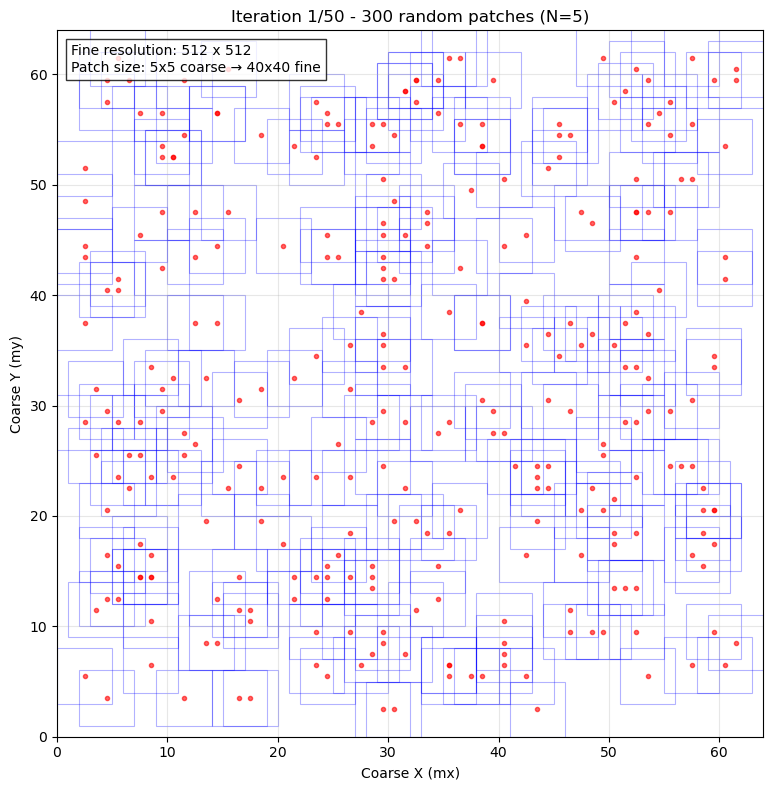

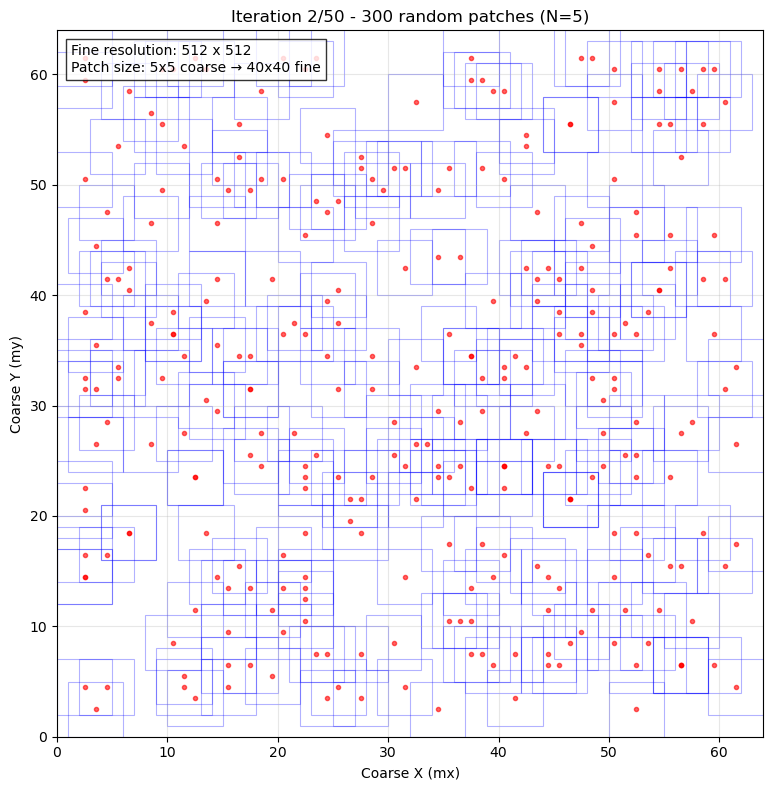

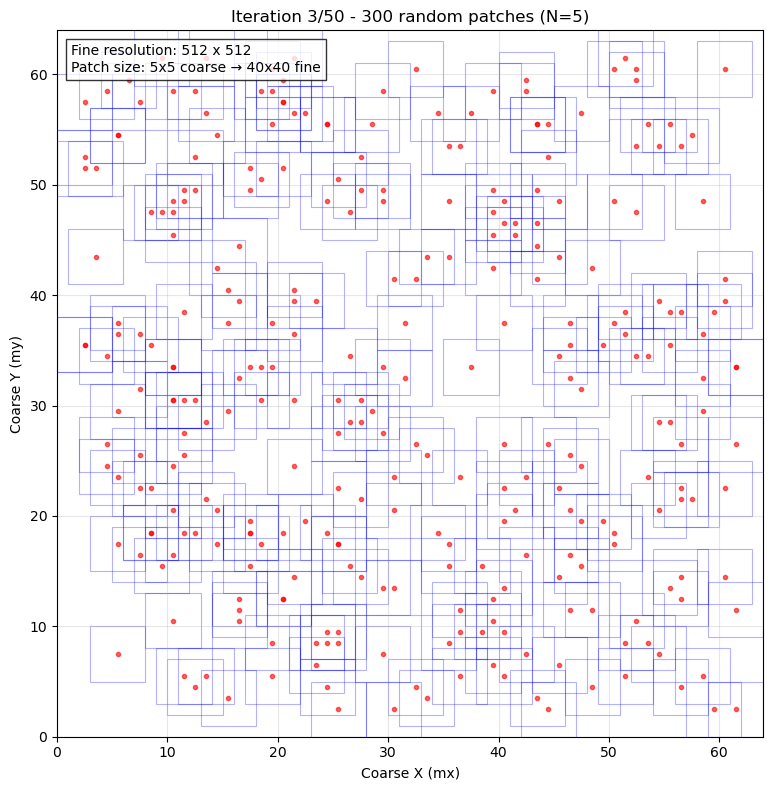

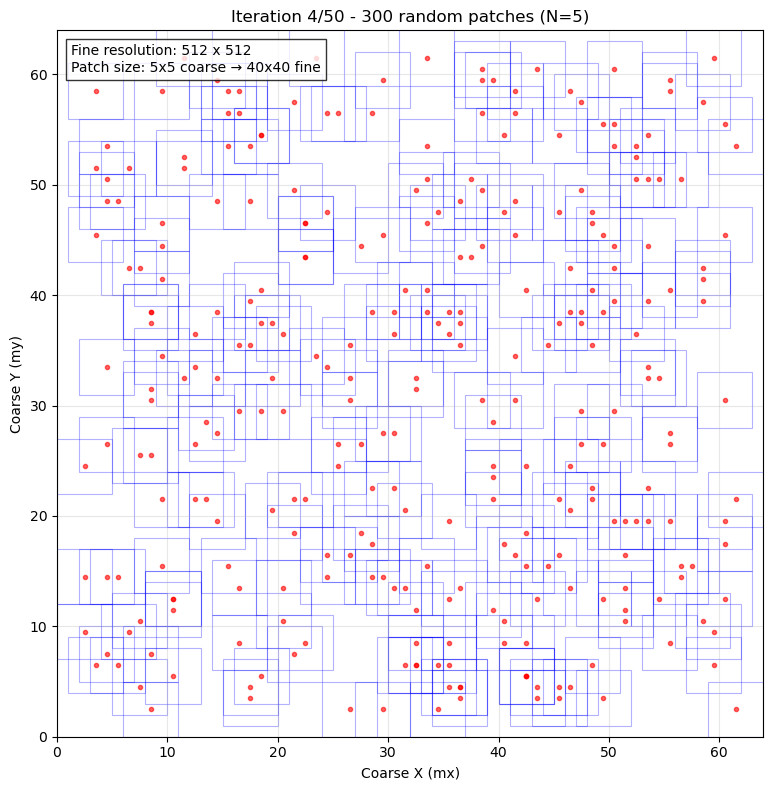

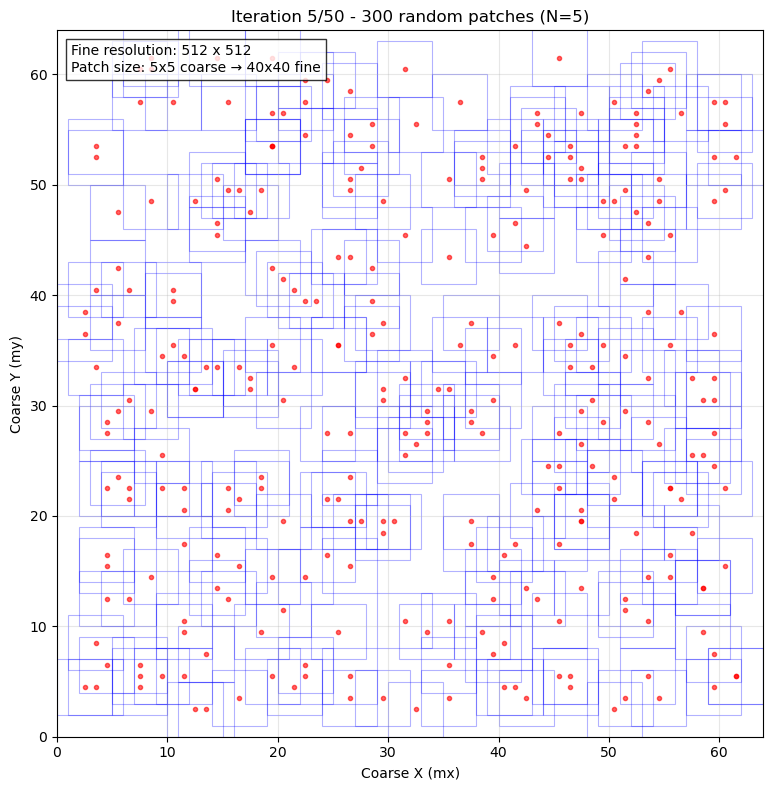

KeyboardInterrupt: 

In [2]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ------------------------------------------------------------------
# Function to plot magnifier placements for each iteration
# ------------------------------------------------------------------
def visualize_magnifier_placements(
    mx, my, N, f, num_iterations=50, patches_per_iter=300
):
    """
    Visualizes the random placement of N x N magnifier patches for each iteration.
    
    - Plots coarse grid [mx, my]
    - Each patch center is marked with a dot
    - Patch boundary shown as rectangle
    - One figure per iteration (or subplots)
    """
    fig_width = 12
    fig_height = 8

    for it in range(num_iterations):
        # Simulate random patch starts (same logic as your inference)
        i_starts = torch.randint(0, mx - N + 1, (patches_per_iter,))
        j_starts = torch.randint(0, my - N + 1, (patches_per_iter,))

        # Create figure for this iteration
        plt.figure(figsize=(fig_width, fig_height))
        ax = plt.gca()

        # Plot coarse grid background
        ax.set_xlim(0, mx)
        ax.set_ylim(0, my)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_title(f"Iteration {it+1}/{num_iterations} - {patches_per_iter} random patches (N={N})")
        ax.set_xlabel("Coarse X (mx)")
        ax.set_ylabel("Coarse Y (my)")

        # Draw each patch as a rectangle + center dot
        for i, j in zip(i_starts, j_starts):
            # Patch rectangle: bottom-left = (j, i), width=N, height=N
            rect = patches.Rectangle(
                (j.item(), i.item()), N, N,
                linewidth=0.8, edgecolor='blue', facecolor='none', alpha=0.3
            )
            ax.add_patch(rect)

            # Center dot
            center_x = j.item() + N / 2
            center_y = i.item() + N / 2
            ax.plot(center_x, center_y, 'ro', markersize=3, alpha=0.6)

        # Optional: show fine grid scale reference
        ax.text(0.02, 0.98, f"Fine resolution: {mx*f} x {my*f}\nPatch size: {N}x{N} coarse → {N*f}x{N*f} fine",
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8))

        plt.tight_layout()
        plt.show()

        # Optional: save each figure
        # plt.savefig(f"placement_iter_{it+1}.png", dpi=150)
        # plt.close()

    print(f"Visualized {num_iterations} iterations of random patch placements.")


# ------------------------------------------------------------------
# Run the visualization (adjust parameters as needed)
# ------------------------------------------------------------------
if __name__ == "__main__":
    # Your domain parameters
    mx, my = 64, 64          # Coarse grid size
    N = 5                    # Coarse patch size
    f = 8                    # Upscaling factor (for reference only)
    num_iterations = 50      # Number of iterations to plot
    patches_per_iter = 300   # Patches per iteration

    print(f"Visualizing placements on coarse grid {mx}x{my}")
    print(f"Patch size: {N}x{N} | Patches per iteration: {patches_per_iter}")

    visualize_magnifier_placements(
        mx=mx,
        my=my,
        N=N,
        f=f,
        num_iterations=num_iterations,
        patches_per_iter=patches_per_iter
    )

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# Dummy magnifier (same as before)
# ------------------------------------------------------------------
def dummy_magnifier(patch_input):
    out = patch_input[:, 0:1, :, :, :] + torch.randn_like(patch_input[:, 0:1, :, :, :]) * 0.03
    return out


# ------------------------------------------------------------------
# Prepare patch input (same as before)
# ------------------------------------------------------------------
def prepare_patch_input(coarse_u, fine_bed, i_start, j_start, N, f, device):
    nb, nt = coarse_u.shape[0], coarse_u.shape[-1]
    P_fine = N * f

    coarse_patch = coarse_u[:, i_start:i_start+N, j_start:j_start+N, :]
    coarse_patch = coarse_patch.permute(0, 3, 1, 2)
    interp_u = F.interpolate(coarse_patch, scale_factor=(f, f), mode='bilinear', align_corners=False)
    interp_u = interp_u.permute(0, 2, 3, 1)

    i_f = i_start * f
    j_f = j_start * f
    bed_patch = fine_bed[:, i_f:i_f + P_fine, j_f:j_f + P_fine]
    bed_patch = bed_patch.unsqueeze(-1).expand(-1, -1, -1, nt)

    patch_input = torch.cat([interp_u.unsqueeze(1), bed_patch.unsqueeze(1)], dim=1)
    return patch_input.to(device)


# ------------------------------------------------------------------
# Inference loop that returns accumulated + weight_map for analysis
# ------------------------------------------------------------------
def run_inference_and_get_coverage(
    coarse_u, fine_bed, N=5, f=8, num_iterations=50, overlap_ratio=0.5, device='cuda'
):
    nb, mx, my, nt = coarse_u.shape
    nx, ny = fine_bed.shape[1], fine_bed.shape[2]
    P_fine = N * f

    accumulated = torch.zeros(nb, nx, ny, nt, device=device)
    weight_map = torch.zeros(nb, nx, ny, nt, device=device)

    step_x = max(1, int(N * (1 - overlap_ratio)))
    step_y = max(1, int(N * (1 - overlap_ratio)))

    for it in range(num_iterations):
        print(f"  Iteration {it+1}/{num_iterations}", end='\r')

        i_starts = torch.arange(0, mx - N + 1, step_x, device=device)
        j_starts = torch.arange(0, my - N + 1, step_y, device=device)

        jitter_i = torch.randint(-step_x//2, step_x//2 + 1, i_starts.shape, device=device)
        jitter_j = torch.randint(-step_y//2, step_y//2 + 1, j_starts.shape, device=device)
        i_starts = (i_starts + jitter_i).clamp(0, mx - N)
        j_starts = (j_starts + jitter_j).clamp(0, my - N)

        for i_start in i_starts:
            for j_start in j_starts:
                i, j = i_start.item(), j_start.item()

                patch_input = prepare_patch_input(coarse_u, fine_bed, i, j, N, f, device)
                patch_output = dummy_magnifier(patch_input)

                i_fine = i * f
                j_fine = j * f

                accumulated[:, i_fine:i_fine+P_fine, j_fine:j_fine+P_fine, :] += patch_output.squeeze(1)
                weight_map[:, i_fine:i_fine+P_fine, j_fine:j_fine+P_fine, :] += 1

    high_res_u = accumulated / weight_map.clamp(min=1e-6)
    return high_res_u, weight_map



def run_full_domain_inference_pure_random(
    coarse_u, fine_bed, N=5, f=8, num_iterations=50, patches_per_iter=300, device='cuda'
):
    nb, mx, my, nt = coarse_u.shape
    nx, ny = fine_bed.shape[1], fine_bed.shape[2]
    P_fine = N * f

    accumulated = torch.zeros(nb, nx, ny, nt, device=device)
    weight_map = torch.zeros(nb, nx, ny, nt, device=device)

    print(f"Pure random sampling: {patches_per_iter} patches per iteration, {num_iterations} iterations")

    for it in range(num_iterations):
        print(f"  Iteration {it+1}/{num_iterations}", end='\r')

        # Pure random starts (no grid!)
        i_starts = torch.randint(0, mx - N + 1, (patches_per_iter,), device=device)
        j_starts = torch.randint(0, my - N + 1, (patches_per_iter,), device=device)

        for idx in range(patches_per_iter):
            i = i_starts[idx].item()
            j = j_starts[idx].item()

            patch_input = prepare_patch_input(coarse_u, fine_bed, i, j, N, f, device)
            patch_output = dummy_magnifier(patch_input)

            i_fine = i * f
            j_fine = j * f

            accumulated[:, i_fine:i_fine+P_fine, j_fine:j_fine+P_fine, :] += patch_output.squeeze(1)
            weight_map[:, i_fine:i_fine+P_fine, j_fine:j_fine+P_fine, :] += 1

    high_res_u = accumulated / weight_map.clamp(min=1e-6)

    print(f"\nFinal high-resolution shape: {high_res_u.shape}")
    print(f"Coverage stats: min={weight_map.min().item():.1f}, max={weight_map.max().item():.1f}, mean={weight_map.mean().item():.1f}")

    return high_res_u, weight_map

# ------------------------------------------------------------------
# Plot histogram of coverage distribution
# ------------------------------------------------------------------
def plot_coverage_histogram(weight_map, title="Coverage Distribution (Number of Times Each Pixel Was Processed)"):
    # Flatten weight_map to 1D (ignore batch dim if nb=1)
    coverage = weight_map.squeeze(0).cpu().numpy().flatten()  # [nx*ny*nt]
    coverage = coverage[coverage > 0]  # remove uncovered (if any)

    plt.figure(figsize=(10, 6))
    plt.hist(coverage, bins=50, color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel("Number of Times Pixel Was Processed")
    plt.ylabel("Number of Pixels")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print stats
    print(f"Coverage Stats:")
    print(f"  Min: {np.min(coverage):.1f}")
    print(f"  Max: {np.max(coverage):.1f}")
    print(f"  Mean: {np.mean(coverage):.1f}")
    print(f"  Median: {np.median(coverage):.1f}")
    print(f"  Std: {np.std(coverage):.1f}")


# ------------------------------------------------------------------
# Run the full test
# ------------------------------------------------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Dummy data (same as your run)
    nb = 1
    mx, my = 40, 20
    nx, ny = 320, 160
    nt = 15
    f = 8
    N = 3

    coarse_u = torch.randn(nb, mx, my, nt, device=device)
    fine_bed = torch.randn(nb, nx, ny, device=device)

    print(f"Coarse u: {coarse_u.shape}")
    print(f"Fine bed: {fine_bed.shape}")

    # Run inference and get weight_map
    _, weight_map = run_full_domain_inference_pure_random(
        coarse_u=coarse_u,
        fine_bed=fine_bed,
        N=N,
        f=f,
        num_iterations=50,
        device=device
    )

    # # Run inference and get weight_map
    # _, weight_map = run_inference_and_get_coverage(
    #     coarse_u=coarse_u,
    #     fine_bed=fine_bed,
    #     N=N,
    #     f=f,
    #     num_iterations=50,
    #     overlap_ratio=0.5,
    #     device=device
    # )

    # Plot histogram
    plot_coverage_histogram(weight_map)